# Part 1: v-Prediction Flow Matching at `D = 2`

In [1]:
from src.model import JiM
from src.train import train_n_steps
from src.denoiser import Denoiser
from src.dataloader import get_dataloader

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

### Helper Functions

In [7]:
N_GEN = 2048

In [8]:
def scatter_plot(generated, truth=None, title="Scatter Plot"):
    plt.figure(figsize=(8, 6))
    if truth is not None:
        plt.scatter(truth[:, 0], truth[:, 1],
                    alpha=0.3, s=10, c="gray", label="ground truth")
    plt.scatter(generated[:, 0], generated[:, 1],
                alpha=0.6, s=10, c="C0", label="generated")
    plt.title(title)
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.gca().set_aspect("equal")
    plt.legend(loc="upper right", framealpha=0.9)
    plt.tight_layout()
    plt.show()

def loss_plot(loss, title="Training Loss", log_scale=True):
    epochs, values = zip(*loss)
    
    plt.figure(figsize=(8, 6))
    plt.plot(epochs, values)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    if log_scale:
        plt.yscale("log")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [9]:
device = torch.device('cuda')

step    500/25000  loss 1.080076
step   1000/25000  loss 1.009736
step   1500/25000  loss 0.990903
step   2000/25000  loss 0.976203
step   2500/25000  loss 0.966759
step   3000/25000  loss 0.960228
step   3500/25000  loss 0.957934
step   4000/25000  loss 0.959980
step   4500/25000  loss 0.957123
step   5000/25000  loss 0.954498
step   5500/25000  loss 0.955193
step   6000/25000  loss 0.951947
step   6500/25000  loss 0.955944
step   7000/25000  loss 0.953968
step   7500/25000  loss 0.950579
step   8000/25000  loss 0.951631
step   8500/25000  loss 0.950175
step   9000/25000  loss 0.951836
step   9500/25000  loss 0.951065
step  10000/25000  loss 0.951413
step  10500/25000  loss 0.950846
step  11000/25000  loss 0.950219
step  11500/25000  loss 0.949830
step  12000/25000  loss 0.949360
step  12500/25000  loss 0.949114
step  13000/25000  loss 0.948869
step  13500/25000  loss 0.947861
step  14000/25000  loss 0.950647
step  14500/25000  loss 0.949132
step  15000/25000  loss 0.949377
step  1550

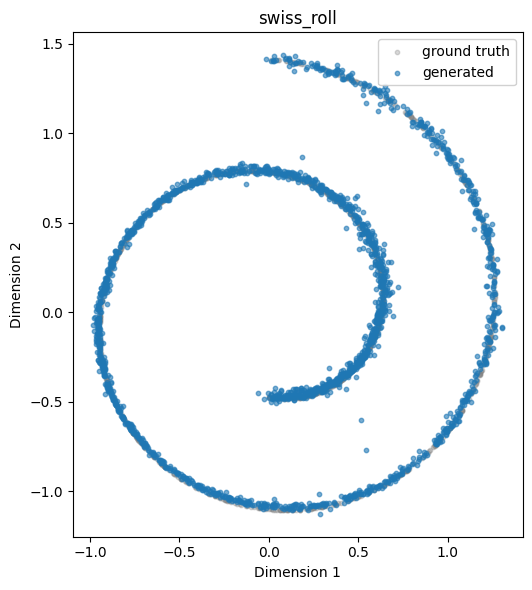

In [10]:
# Dataloader
dataloader = get_dataloader(name="swiss_roll", dim=2, batch_size=1024)
# MLP Model
model = JiM(hidden_dim=256, D=2)
model = model.to(device)
# Optimiser
opt = optim.Adam(model.parameters(), lr=1e-3)
# Train Steps
train_steps = 25000
# Denoising steps
steps = 50

# Train
loss = train_n_steps(model, dataloader, opt, device, train_steps, 'v', 'v',)

# Generate
denoiser = Denoiser(model, steps=steps, D=2)
out = denoiser.generate(N_GEN, 'v', device)
truth = next(iter(dataloader))[:N_GEN].cpu().numpy()

scatter_plot(out.cpu(), truth, title="swiss_roll")

step    500/25000  loss 1.054830
step   1000/25000  loss 0.943560
step   1500/25000  loss 0.928566
step   2000/25000  loss 0.922932
step   2500/25000  loss 0.916898
step   3000/25000  loss 0.920216
step   3500/25000  loss 0.919194
step   4000/25000  loss 0.916321
step   4500/25000  loss 0.918812
step   5000/25000  loss 0.913235
step   5500/25000  loss 0.911034
step   6000/25000  loss 0.911504
step   6500/25000  loss 0.913728
step   7000/25000  loss 0.912064
step   7500/25000  loss 0.909591
step   8000/25000  loss 0.910732
step   8500/25000  loss 0.912624
step   9000/25000  loss 0.907647
step   9500/25000  loss 0.911799
step  10000/25000  loss 0.908757
step  10500/25000  loss 0.908781
step  11000/25000  loss 0.909036
step  11500/25000  loss 0.905001
step  12000/25000  loss 0.908979
step  12500/25000  loss 0.908619
step  13000/25000  loss 0.908896
step  13500/25000  loss 0.908335
step  14000/25000  loss 0.909353
step  14500/25000  loss 0.904645
step  15000/25000  loss 0.907068
step  1550

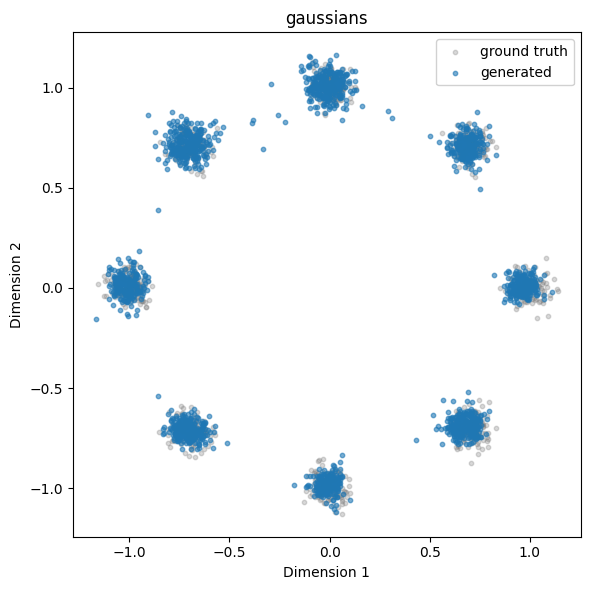

In [11]:
# Dataloader
dataloader = get_dataloader(name="gaussians", dim=2, batch_size=1024)
# MLP Model
model = JiM(hidden_dim=256, D=2)
model = model.to(device)
# Optimiser
opt = optim.Adam(model.parameters(), lr=1e-3)
# Train Steps
train_steps = 25000
# Denoising steps
steps = 50

# Train
loss = train_n_steps(model, dataloader, opt, device, train_steps, 'v', 'v',)

# Generate
denoiser = Denoiser(model, steps=steps, D=2)
out = denoiser.generate(N_GEN, 'v', device)
truth = next(iter(dataloader))[:N_GEN].cpu().numpy()

scatter_plot(out.cpu(), truth, title="gaussians")

step    500/25000  loss 0.926895
step   1000/25000  loss 0.873399
step   1500/25000  loss 0.869794
step   2000/25000  loss 0.867392
step   2500/25000  loss 0.863504
step   3000/25000  loss 0.859089
step   3500/25000  loss 0.851714
step   4000/25000  loss 0.847915
step   4500/25000  loss 0.845947
step   5000/25000  loss 0.845678
step   5500/25000  loss 0.845257
step   6000/25000  loss 0.841703
step   6500/25000  loss 0.841386
step   7000/25000  loss 0.843478
step   7500/25000  loss 0.841980
step   8000/25000  loss 0.841508
step   8500/25000  loss 0.839931
step   9000/25000  loss 0.843333
step   9500/25000  loss 0.843042
step  10000/25000  loss 0.839350
step  10500/25000  loss 0.840215
step  11000/25000  loss 0.840050
step  11500/25000  loss 0.840411
step  12000/25000  loss 0.839269
step  12500/25000  loss 0.838764
step  13000/25000  loss 0.839363
step  13500/25000  loss 0.838781
step  14000/25000  loss 0.838739
step  14500/25000  loss 0.837856
step  15000/25000  loss 0.839142
step  1550

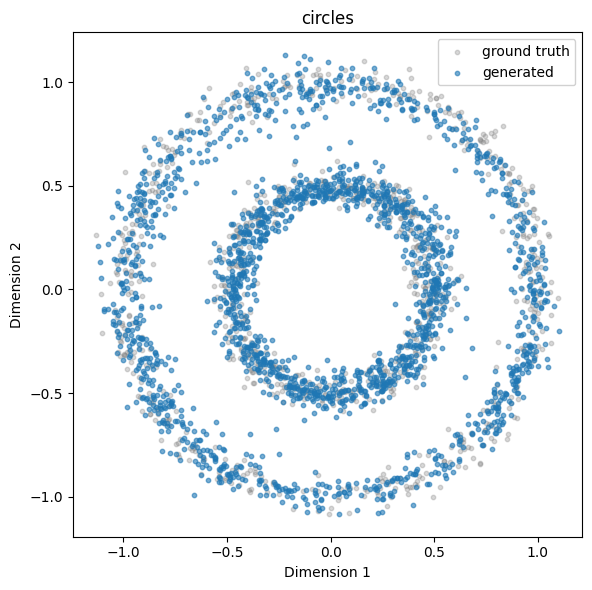

In [12]:
# Dataloader
dataloader = get_dataloader(name="circles", dim=2, batch_size=1024)
# MLP Model
model = JiM(hidden_dim=256, D=2)
model = model.to(device)
# Optimiser
opt = optim.Adam(model.parameters(), lr=1e-3)
# Train Steps
train_steps = 25000
# Denoising steps
steps = 50

# Train
loss = train_n_steps(model, dataloader, opt, device, train_steps, 'v', 'v',)

# Generate
denoiser = Denoiser(model, steps=steps, D=2)
out = denoiser.generate(N_GEN, 'v', device)
truth = next(iter(dataloader))[:N_GEN].cpu().numpy()

scatter_plot(out.cpu(), truth, title="circles")